# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:**  Group 10
- **Student Names:**  
  -  Jacob Miller
  -  Daniel Klingensmith
  -  Ilton Da Costa Neto
  - Varun Suresh Kumar
  

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team’s own work.

## Dataset
You will work with a realistic “messy” customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [ ]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
# If 'synthetic_churn.csv' is not present, this cell will generate it.
# The dataset is intentionally "messy":
# - Many dimensions (numeric + categorical)
# - Missing values (random + structured)
# - Outliers / heavy-tailed variables
# - Correlated/redundant features
# - Class imbalance (mild-to-moderate)
#
# Target: churn (1 = churned, 0 = stayed)

import numpy as np
import pandas as pd

from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000

    # Core demographics / account
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)  # heavy-tailed
    household_size = rng.integers(1, 7, size=n)

    # Usage / behavior
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)  # right-skew
    days_since_last_login = rng.integers(0, 60, size=n)

    # Payments / billing
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)

    # Product / plan
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)

    # Geography + channel
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)

    # Noisy / redundant engineered features
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    # correlated with total_charges
    total_charges_rounded = np.round(total_charges / 10) * 10
    # redundant variation on logins
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)

    # Introduce outliers: a small fraction of extreme monthly fees and income
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))

    # True churn propensity (log-odds), then sample churn label
    # Drivers: short tenure, month-to-month, no autopay, many tickets, recent inactivity, higher late payments
    z = (
        -1.2
        + 0.015*(days_since_last_login)
        + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m)
        - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int)
        - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int)
        + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int)
        + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int)
        + rng.normal(0, 0.35, size=n)
    )

    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)

    df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "income": income,
        "household_size": household_size,
        "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login,
        "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m,
        "autopay": autopay,
        "contract": contract,
        "plan": plan,
        "add_ons": add_ons,
        "streaming": streaming,
        "region": region,
        "signup_channel": signup_channel,
        "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded,
        "engagement_score": engagement_score,
        "churn": churn
    })

    # Inject missingness (both random and structured)
    # Random missingness
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    # Structured: customers with very low tenure often missing total charges (new customers)
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan

    # Slight label noise (realistic)
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]

    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


✅ Generated dataset: /content/synthetic_churn.csv with shape (6000, 21)


## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [ ]:
# (INGEST)
import pandas as pd

# 1) Load
df = pd.read_csv('synthetic_churn.csv')

# 2) Inspect
display(df.shape)
display(df.head())
display(df.dtypes)

# 3) Missingness summary (counts + percent)
print('Missingness summary')
print('Total null count:')
print(df.isna().any(axis=1).sum())
print('Null count by column:')
print(df.isna().sum())
print('Nulls as a percentage of total:')
percentage = (100*(df.isna().any(axis=1).sum() / len(df)))
print('%'+str(percentage))
print('Outliers with z-score > 3:')
numericals = df.select_dtypes(include="number")
z_scores = (numericals - numericals.mean()) / numericals.std()
outlier_rows = df[(np.abs(z_scores) > 3).any(axis=1)]
print(outlier_rows.shape)

# Columns include '...' (unneeded), 'total_charges' as well as 'total_charges_rounded', which is redundant.
# Nulls exist on income, avg_session_mins, monthly_fee, streaming, region, total_charges; they comprise ~34% of the data, so they cannot simply be discarded
# Outliers likely need to be dealt with on income and monthly_fee



(6000, 21)

,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,...,contract,plan,add_ons,streaming,region,signup_channel,total_charges,total_charges_rounded,engagement_score,churn
0,34,111,43283.836559,3,6,1,8.015632,37,75.741544,1,...,Month-to-month,Pro,3,Both,Midwest,Web,8393.730283,8390.0,0.090024,0
1,23,74,45608.528368,6,14,2,10.078930,44,100.957688,1,...,One year,Basic,1,Both,South,Web,7654.510301,7650.0,0.193464,1
2,69,113,31254.972376,2,9,0,23.226331,37,30.898616,1,...,One year,Pro,2,Both,South,Web,3662.195331,3660.0,0.178748,0
3,65,97,28989.989283,6,22,1,16.334476,14,105.354848,1,...,One year,Basic,3,Both,South,Phone,10144.071051,10140.0,0.479665,0
4,46,43,107671.977983,2,14,3,5.636188,6,99.973303,1,...,Month-to-month,Plus,0,Video,Northeast,Phone,4372.902650,4370.0,0.404659,0


,0
age,int64
tenure_months,int64
income,float64
household_size,int64
logins_30d,int64
support_tickets_90d,int64
avg_session_mins,float64
days_since_last_login,int64
monthly_fee,float64
late_payments_12m,int64


Missingness summary
Total null count:
2050
Null count by column:
age                         0
tenure_months               0
income                    350
household_size              0
logins_30d                  0
support_tickets_90d         0
avg_session_mins          338
days_since_last_login       0
monthly_fee               195
late_payments_12m           0
autopay                     0
contract                    0
plan                        0
add_ons                     0
streaming                1251
region                    113
signup_channel              0
total_charges              90
total_charges_rounded      90
engagement_score            0
churn                       0
dtype: int64
Nulls as a percentage of total:
%34.166666666666664
Outliers with z-score > 3:
(299, 21)


### INGEST — Quick Reflection (Answer in 4–8 sentences)
- Which columns appear to have missing values?

**The dataset shows missing values in several columns, with streaming missing the most (1251, 20.9%), followed by income (250, 5.83%), avg_session_mins	(338, 5.63%), monthly_fee(195, 3.25%), region(113, 1.88%), total_charges(90, 1.5%), and total_charges_rounded(90, 1.5%)**
- Which columns look categorical vs numeric?  

**Categorical columns seem to include autopay, contract, plan, streaming, region, and signup_channel as they are all object dtype.**

**Numeric columns would be the rest, including age, tenure_months, income, household_size, logins_30d, support_tickets_90d, avg_session_mins, days_since_last_login, monthly_fee, late_payments_12m, add_ons, total_charges, total_charges_rounded, engagement_score, and churn.**
- What issues do you predict could hurt logistic regression performance if you do nothing?

**Issues that could occur if left unaddressed include:**

**- Missing Values would prevent the model from training or cause errors.**

**- Outliers and skewed distributions visible in the variables, such as income and monthly_fee, could dominate the model.**

**- Redundant features like total_charges and total_charges_rounded are highly correlated and since they provide overlapping information which can make the model coefficients less stable.**


## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew (suggestions: `income`, `monthly_fee`, `total_charges`, `avg_session_mins`).
3. Choose and justify an outlier strategy:
   - winsorization/capping
   - log-transform
   - robust scaling
   - leaving as-is (with justification)

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (i.e., implementable in code and applied consistently).

**Deliverable:** A short markdown justification of your decisions.


In [ ]:
import numpy as np

# Dropping redundant/unnecessary columns
df_cleaned = df.drop(columns=['total_charges_rounded'])

# Missing value cleanup
# Values to clean: income, avg_session_mins, monthly_fee, streaming, region, total_charges


# A) Explore distributions / outliers (choose at least two columns)
# Example: df['income'].describe()

# B) Decide on a strategy for skew/outliers
# - If transforming, create new columns (do not overwrite originals unless you justify it)
# - If capping, implement caps using quantiles (e.g., 1st and 99th percentiles)

#List of numerical columns that contain missing values
cols_to_examine = ['income', 'monthly_fee', 'total_charges', 'avg_session_mins']

display(df_cleaned[cols_to_examine].quantile([0.01, 0.99]))

for col in cols_to_examine:
  #Clip the top and bottom quantile
    lower_limit = df_cleaned[col].quantile(0.01)
    upper_limit = df_cleaned[col].quantile(0.99)
    df_cleaned[col] = df_cleaned[col].clip(lower_limit, upper_limit)

    #Replace missing numerical values with the average from existing values
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

#Fill missing string values with 'Unknown'
df_cleaned['region'] = df_cleaned['region'].fillna('Unknown')
df_cleaned['streaming'] = df_cleaned['streaming'].fillna('Unknown')

print('Null count by column:')
print(df_cleaned.isna().sum())





,income,monthly_fee,total_charges,avg_session_mins
0.01,14180.321470,23.539128,99.814078,1.653748
0.99,137210.408231,113.878237,10375.857002,56.495674


Null count by column:
age                      0
tenure_months            0
income                   0
household_size           0
logins_30d               0
support_tickets_90d      0
avg_session_mins         0
days_since_last_login    0
monthly_fee              0
late_payments_12m        0
autopay                  0
contract                 0
plan                     0
add_ons                  0
streaming                0
region                   0
signup_channel           0
total_charges            0
engagement_score         0
churn                    0
dtype: int64


### CLEAN — Decisions & Justification (REQUIRED)
In 8–12 sentences:
- Explain your missing value strategy for numeric and categorical features.
  **For numerical values, we imputed missing numbers with the mean of the extant numbers (after dropping outliers to avoid skew). For categorical values, given the relatively small number of categories, we opted to add a new value of 'Unknown' to stand in- which could allow detection of if the missing categorical data is correlated to c**

- Identify which variables had outliers/skew and what you did about them.

  **We cleaned the missing values and outliers using a consistent and repeatable process. For numeric columns(income, monthly_fee, total_charges, and avg_session_mins), we first applied a lower and upper cutoff at the 1st and 99th percentiles to try and reduce the effect of extreme values. Afterwards, we handled the missing values in the numeric features by using mean imputation so that we could keep rows and avoid dropping data. For the categorical features, we filled in the missing values using an "Unknown" label. We chose this to try and preserve missingness as potentially meaningful information. We also dropped total_charges_rounded as it was a redundant version of total_charges and adds overlapping information.**

- Explain the tradeoff of your choice (what you might lose vs gain).

  **This strategy improves model stability by preventing a small number of extreme observations from dominating logistic regression coefficients. It also allows us to keep a full dataset size, which can help avoid potential bias from deleting records. The tradeoff is that capping can reduce genuin signal in true extreme customers, and as such, mean-based filling may shrink natural variation in numeric features.**



## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables **if you choose** (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.

**Deliverable:** Your final preprocessing pipeline.


In [ ]:
# (PREPARE)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1) X, y
y = df_cleaned['churn']
X = df_cleaned.drop(columns=['churn'])

# 2) Identify numeric vs categorical columns
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="string").columns.tolist()
print(num_cols)

# 3) Split (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=13)

# 4) Build preprocessors:
# - Numeric: impute + (optional) scaling
# - Categorical: impute + one-hot encode
# numeric_transformer = ...
# categorical_transformer = ...

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 5) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop" # Ensures no extra columns leak through
)


['age', 'tenure_months', 'income', 'household_size', 'logins_30d', 'support_tickets_90d', 'avg_session_mins', 'days_since_last_login', 'monthly_fee', 'late_payments_12m', 'add_ons', 'total_charges', 'engagement_score']


## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider:
   - regularization strength (`C`)
   - solver
   - max iterations
   - class imbalance (`class_weight="balanced"` vs not)

**Required:** Train at least **two** model variants and compare them briefly.


In [ ]:
# (MODEL)
from sklearn.linear_model import LogisticRegression

# Model variant A
clf_a = LogisticRegression()
model_a = Pipeline(steps=[("preprocess", preprocessor), ("model", clf_a)])
model_a.fit(X_train, y_train)

# Model variant B - different C value
clf_b = LogisticRegression(C=.1)
model_b = Pipeline(steps=[("preprocess", preprocessor),
                         ("model", clf_b)])
model_b.fit(X_train, y_train)

# Model variant C - different class weight
clf_c = LogisticRegression(class_weight='balanced')
model_c = Pipeline(steps=[("preprocess", preprocessor),
                         ("model", clf_c)])
model_c.fit(X_train, y_train)

# Model variant D - different solver
clf_d = LogisticRegression(solver="newton-cholesky")
model_d = Pipeline(steps=[("preprocess", preprocessor), ("model", clf_d)])
model_d.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tenure_months',
                                                   'income', 'household_size',
                                                   'logins_30d',
                                                   'support_tickets_90d',
                                                   'avg_session_mins',
                                                   'days_since_last_login',
                                                   'monthly_fee',
                                                   'late_payments_12m',
                                                   'add_ons', 'total_charges',
                                                   'engagement_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [])])),
                ('model', LogisticRegression(solver='newton-cholesky'))])

## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret:
   - confusion matrix
   - accuracy, precision, recall, F1
   - ROC-AUC
   - PR-AUC (average precision)
3. **Threshold tuning (graduate level):**
   - Evaluate thresholds (e.g., 0.2 to 0.8)
   - Choose an “operating threshold” based on a cost scenario
4. Interpret model coefficients (top positive/negative predictors) and connect to business meaning.

### Cost Scenario (Use this)
Assume:
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**

Your goal is to choose a threshold that **minimizes expected cost**.

**Deliverables:** Plots + written justification.


              precision    recall  f1-score   support

           0       0.68      0.94      0.79       801
           1       0.50      0.13      0.20       399

    accuracy                           0.67      1200
   macro avg       0.59      0.53      0.50      1200
weighted avg       0.62      0.67      0.60      1200

              precision    recall  f1-score   support

           0       0.68      0.94      0.79       801
           1       0.51      0.13      0.20       399

    accuracy                           0.67      1200
   macro avg       0.59      0.53      0.50      1200
weighted avg       0.62      0.67      0.59      1200

              precision    recall  f1-score   support

           0       0.73      0.61      0.67       801
           1       0.41      0.55      0.47       399

    accuracy                           0.59      1200
   macro avg       0.57      0.58      0.57      1200
weighted avg       0.63      0.59      0.60      1200

              preci

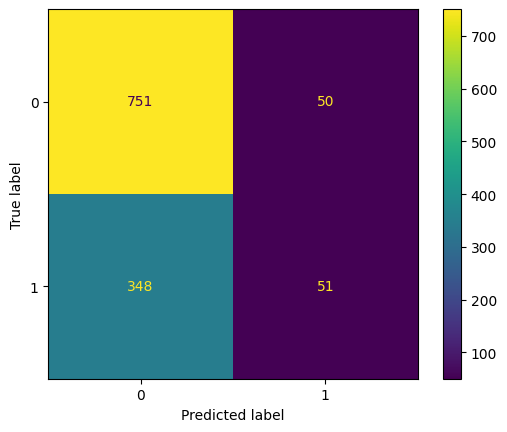

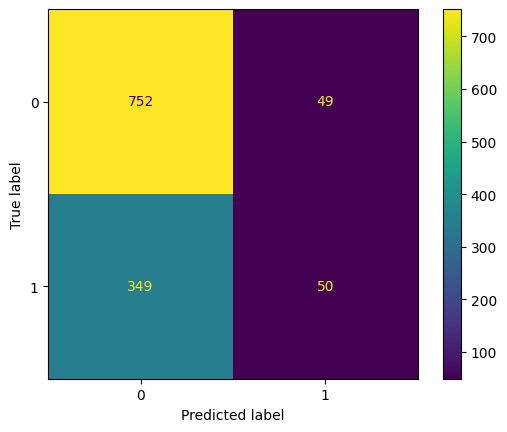

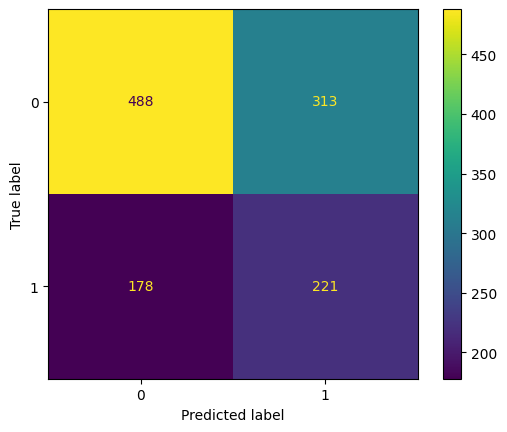

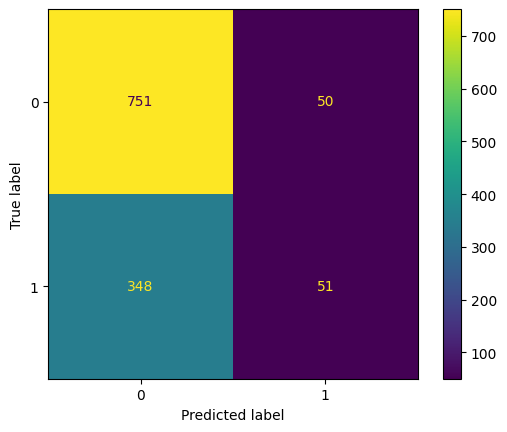

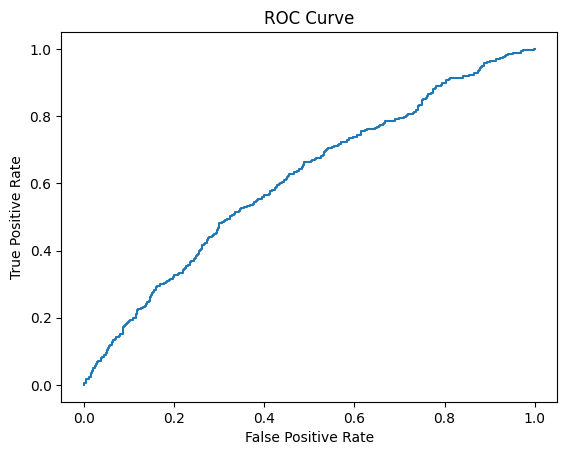

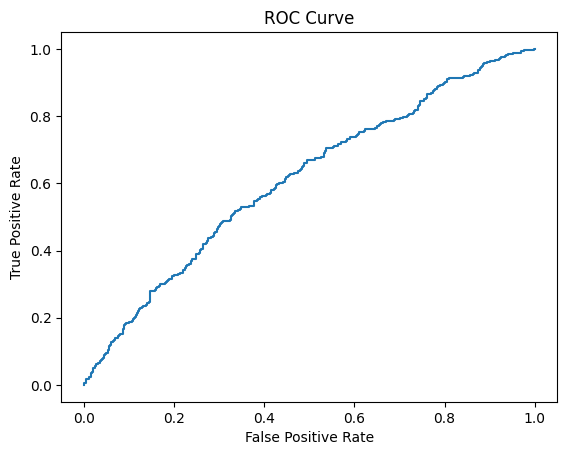

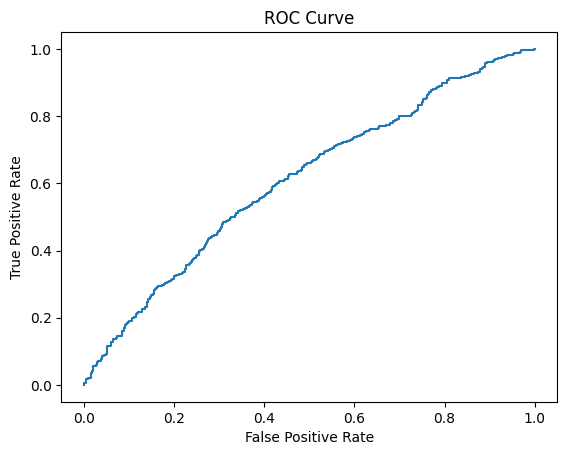

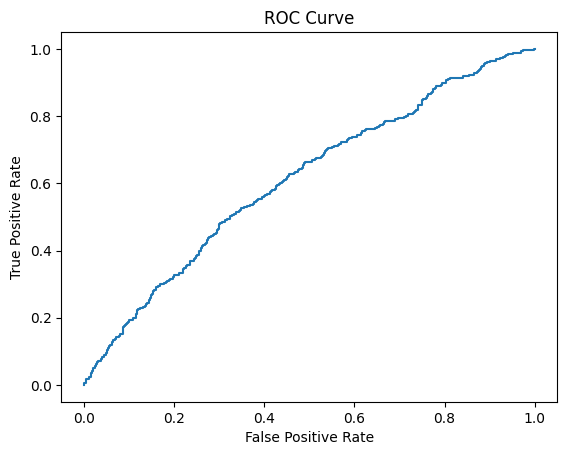

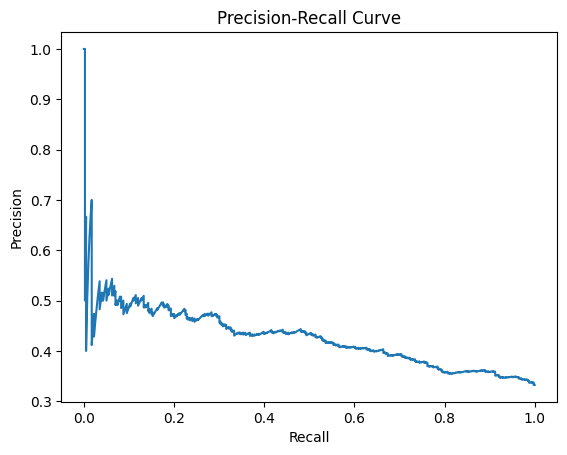

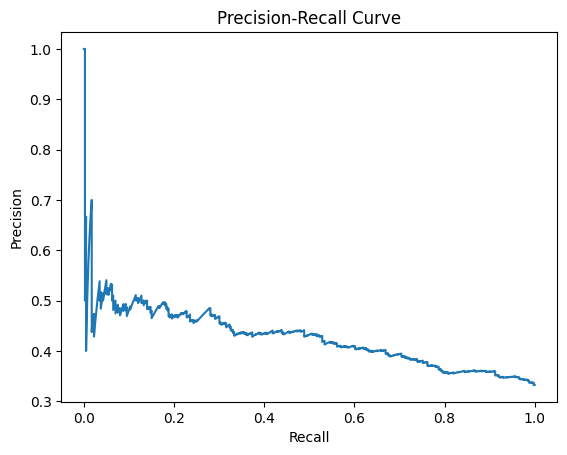

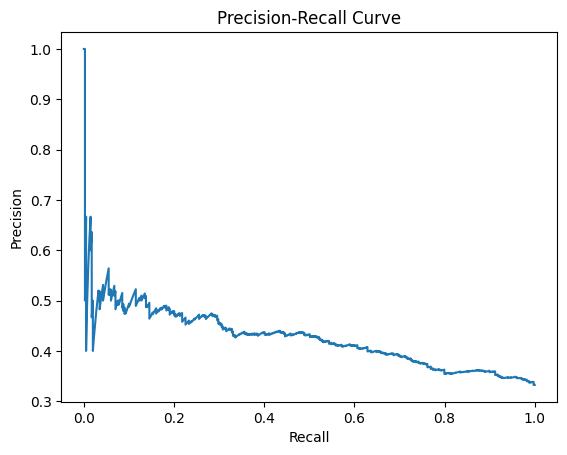

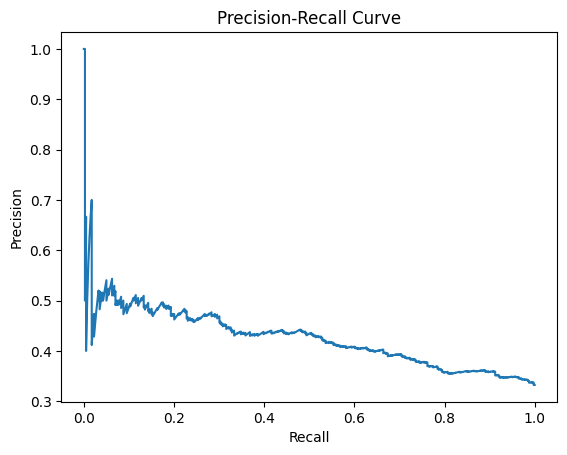

Model 1 with threshold 0.2  has cost 57760
Model 1 with threshold 0.25  has cost 75120
Model 1 with threshold 0.3  has cost 93400
Model 1 with threshold 0.35  has cost 113000
Model 1 with threshold 0.39999999999999997  has cost 140920
Model 1 with threshold 0.44999999999999996  has cost 159040
Model 1 with threshold 0.49999999999999994  has cost 177000
Model 1 with threshold 0.5499999999999999  has cost 187180
Model 1 with threshold 0.5999999999999999  has cost 193720
Model 1 with threshold 0.6499999999999999  has cost 196300
Model 1 with threshold 0.7  has cost 198680
Model 1 with threshold 0.7499999999999998  has cost 198560
Model 1 with threshold 0.7999999999999998  has cost 199500
Model 2 with threshold 0.2  has cost 57320
Model 2 with threshold 0.25  has cost 74980
Model 2 with threshold 0.3  has cost 91460
Model 2 with threshold 0.35  has cost 112940
Model 2 with threshold 0.39999999999999997  has cost 141680
Model 2 with threshold 0.44999999999999996  has cost 158980
Model 2 wit

In [ ]:
# (ANALYZE)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import FixedThresholdClassifier
import matplotlib.pyplot as plt
import numpy as np

# 1) Predict probabilities (needed for threshold tuning)
proba_a = model_a.predict_proba(X_test)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]
proba_c = model_c.predict_proba(X_test)[:, 1]
proba_d = model_d.predict_proba(X_test)[:, 1]

# 2) Default threshold predictions (0.5)
y_pred_a = (proba_a >= 0.5).astype(int)
y_pred_b = (proba_b >= 0.5).astype(int)
y_pred_c = (proba_c >= 0.5).astype(int)
y_pred_d = (proba_d >= 0.5).astype(int)

# 3) Confusion matrix + report
pred_list = [y_pred_a, y_pred_b, y_pred_c, y_pred_d]
for pred in pred_list:
  cm = confusion_matrix(y_test, pred)
  ConfusionMatrixDisplay(cm).plot()
  print(classification_report(y_test, pred))

# 4) ROC-AUC + ROC curve
proba_list = [proba_a, proba_b, proba_c, proba_d]
for proba in proba_list:
  auc = roc_auc_score(y_test, proba)
  fpr, tpr, _ = roc_curve(y_test, proba)
  plt.figure()
  plt.plot(fpr, tpr)
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.show()

# 5) PR curve + Average Precision
for proba in proba_list:
  precision, recall, _ = precision_recall_curve(y_test, proba)
  ap = average_precision_score(y_test, proba)
  plt.figure()
  plt.plot(recall, precision)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title("Precision-Recall Curve")
  plt.show()

# 6) Threshold tuning loop:
thresholds = np.arange(0.2, 0.81, 0.05)
models = [model_a, model_b, model_c, model_d]
model_number = 1
lowest_cost=np.inf
lowest_cost_model=''
lowest_cost_threshold=0
for model in models:
  for threshold in thresholds:
    ftc = FixedThresholdClassifier(estimator=model, threshold=threshold)
    y_pred_ftc = ftc.predict(X_test)
    cm_ftc = confusion_matrix(y_test, y_pred_ftc)
    FN = cm_ftc[1,0]
    FP = cm_ftc[0,1]
    expected_cost = FN*500 + FP*60
    print('Model '+str(model_number)+' with threshold '+str(threshold)+'  has cost '+str(expected_cost))
    if expected_cost < lowest_cost:
      lowest_cost = expected_cost
      lowest_cost_model=model_number
      lowest_cost_threshold=threshold

  model_number=model_number+1

print('Lowest cost was '+str(lowest_cost)+' from model '+str(lowest_cost_model)+' at threshold '+str(lowest_cost_threshold))

#7 Interperet model coefficients
model_number = 1
for model in models:
  feature_names = model[:-1].get_feature_names_out()

  coefs = pd.DataFrame(
      model.steps[-1][1].coef_.transpose(),
      columns=["Coefficients"],
      index=feature_names,
  )
  print("\nModel number "+str(model_number)+' coefficients:')
  print(coefs)
  model_number=model_number+1


### ANALYZE — Written Response (REQUIRED)

Answer ALL parts with complete sentences and concrete numbers.

1) **Model comparison:** Which variant performed better and why (use metrics)?

**Model 3 performed the best for churn detection and business use since it had a higher class-1 recall (0,56) and class-1 F1 (0.48) than the other models (recall 0.12, F1 0.20), even though its overall accuracy (0.59) was lower than theirs (0.67). Since missing churners is expensive, model 3 is the better choice.**

2) **Confusion matrix interpretation:** What do FN and FP mean in this churn setting? Which is “worse” under the cost scenario?  

  **A false negative (FN) means a real churner predicted as "stay", so the business misses the chance to intervene. Whereas, as false positive (FP) means predicting churn for a customer who would have stayed, which causes an unnecessary retention to offer. FN is worse here since it costs $500 versus the $60 for FP.**

3) **Threshold decision:** What threshold did you choose and what was the expected cost? Show your calculation.  

**We chose model 3 at threshold 0.25 because it produced the lowest expected cost: $47,740. The calculation uses Expected Cost = FN * 500 + FP * 60m and this model-threshold pair was lower than the others tested.**

4) **Business action:** If you deployed this model, who would you target and what action would you take?

**We would target customers flagged as churn risk by model 3 at threshold 0.25 and trigger retention actions like proactive outreach, service recovery, or tailored discounts. This would be appropriate because the business should prioritize catching more potential churners when FN cost is much higher.**

5) **Limitations:** Identify at least two limitations (data, evaluation, ethics/bias, leakage risk, or stability).

**One limitation is that this is synthetic data, so real-world customer behavior may differ and reduce performance after deployment. Additionally, our data processing to remove null values and outliers may be excluding valuable insights- many industries get a lot of value out of high value outliers, for example. Another limitation would be model stability over time. This best threshold (0.25) may drift as customer patterns and costs change, so a periodic recalibration may be needed.**